In [1]:
!pip install jupyter
!pip install --upgrade jupyter
!pip install sqlalchemy
!pip install pywaffle missingno
!pip install qbstyles
!pip install ydata-profiling

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import numpy as np
import pandas as pd
xls = pd.ExcelFile("OrganDonor_Consolidated.xlsx")
#Reading the Donor Details sheet
df_DD =pd.read_excel(xls,"DonorDetails")
#Reading the Referra Details sheet
df_RD =pd.read_excel(xls,"ReferralDetails")
#Reading the Outcomes sheet
df_Out =pd.read_excel(xls,"Outcomes")
#Reading the OPO_HospDetails sheet
df_OPO =pd.read_excel(xls,"OPO_HospDetails")
#Reading the Yearly_Outcomess sheet
df_Year =pd.read_excel(xls,"Yearly_Outcomes")

In [6]:
##Q1.Using numpy functions, multiply the following arrays using matrix multiplication. a=np.arange(4).reshape(2,2) b=np.arange(6).reshape(3,2)"

In [7]:
a=np.arange(4).reshape(2,2)
print (a)
b=np.arange(6).reshape(3,2)
print (b)
#For matrix multiplication, we need the number of columns in a to equal the number of rows in b, so transposing b 
b=b.T
print(b)
res=np.matmul(a,b)
print(res)

[[0 1]
 [2 3]]
[[0 1]
 [2 3]
 [4 5]]
[[0 2 4]
 [1 3 5]]
[[ 1  3  5]
 [ 3 13 23]]


In [ ]:
##Q2. On Average, what is the time that passes between approach and procurement?

In [4]:

#Reading the Referral Details sheet
df_RD =pd.read_excel(xls,"ReferralDetails")
# Time difference between 'time_approached' and 'time_procured' in days
df_RD['Time_to_Procurement'] = (df_RD['time_procured'] - df_RD['time_approached']).dt.days
# Average time to procurement
average_time = df_RD['Time_to_Procurement'].mean()
# Print the result
print(f"On average, the time between approach and procurement is {average_time:.2f} days.")

On average, the time between approach and procurement is 3.18 days.


In [ ]:
##Q3. Make Patient ID as index to the table.

In [14]:

#Reading the Donor Details sheet
df_DD =pd.read_excel(xls,"DonorDetails")
index_df=df_DD.set_index('PatientID')
print(index_df.head(10))


               age gender      race              causeofdeath  \
PatientID                                                       
OPO1_P155959  54.0      M     White                   Unknown   
OPO1_P297347  78.0      M  Hispanic                   Unknown   
OPO1_P399316  57.0      M  Hispanic                    Anoxia   
OPO1_P246407  78.0      F     Black  cerebrovascular accident   
OPO1_P187209  70.0      F     White                   Unknown   
OPO1_P867460  51.0      M  Hispanic                   Unknown   
OPO1_P810329  69.0      F     White                   Unknown   
OPO1_P652117  72.0      F  Hispanic                   Unknown   
OPO1_P833594  59.0      F     White                    Anoxia   
OPO1_P193672  61.0      M     Black                    Anoxia   

             mechanism_of_death  brain_death       time_asystole  \
PatientID                                                          
OPO1_P155959            Unknown            0 2036-01-02 18:26:00   
OPO1_P297347   

In [ ]:
##Q4. Create a dictionary with the Age and Cause of Death for any 5 random donors.

In [15]:

#Reading the Donor Details sheet
df_DD =pd.read_excel(xls,"DonorDetails")
age_causeOfDeath=df_DD[['age','causeofdeath']]
random_donors=age_causeOfDeath.sample(n=5, random_state=1)
donor_dict=random_donors.set_index('age')['causeofdeath'].to_dict()
print(f'Dictionary with the Age and Cause of Death for any 5 random donors:\n{donor_dict}')

Dictionary with the Age and Cause of Death for any 5 random donors:
{31.0: 'Anoxia', 69.0: 'cerebrovascular accident', 60.0: 'Exsanguination', 49.0: 'cerebrovascular accident', 59.0: 'Infectious Disease - Viral'}


In [ ]:
##Q5. Create a heatmap on the donor details table.

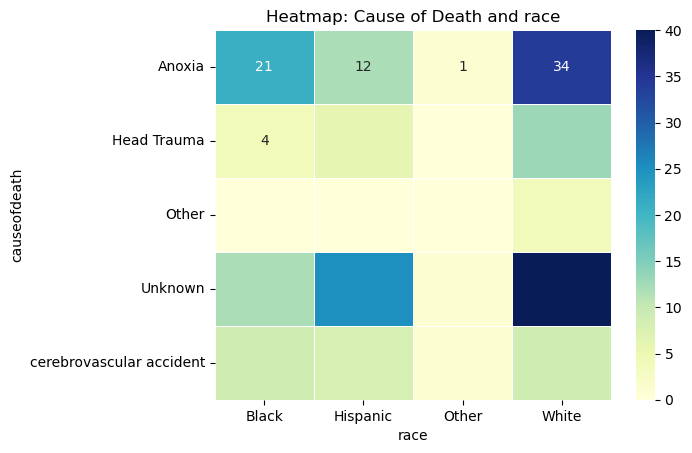

In [17]:
# Selecting the first 200 rows of data for better Vizualization
df_DD_top200 = df_DD.head(200)
# Creating a pivot table for 'causeofdeath' and 'race'
pivot_table = df_DD_top200.pivot_table(index='causeofdeath', columns='race', aggfunc='size', fill_value=0)
# Plotting the heatmap
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt="d", cbar=True, linewidths=0.5)
plt.title('Heatmap: Cause of Death and race')
# Show the plot
plt.show()

In [ ]:
##Q6.Create a box plot on any values in the donor details table

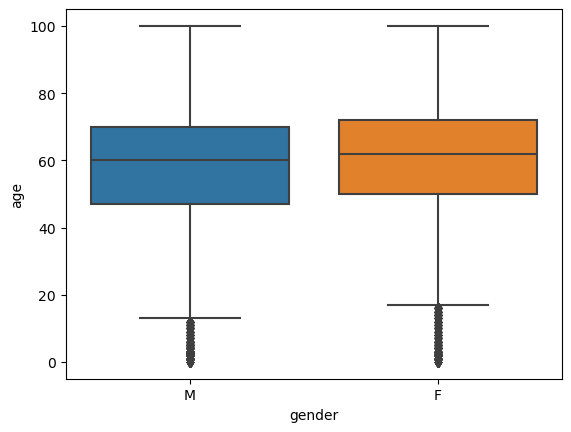

In [5]:
df_DD=pd.read_excel(xls, "DonorDetails")
sns.boxplot(x='gender',y='age',data=df_DD)
plt.show()